# V1 House — collecte & validation, refaites au propre

**But.** Reconstruire de bout en bout la chaîne de récupération des données de la **Chambre
des représentants** (2014-2026) dans un seul notebook auto-suffisant, et la **valider de
l'intérieur** — sans source externe. Ce notebook est aussi un audit de l'ancien pipeline
(`00_S1S2_donnees/`) : à la fin, chaque écart entre les deux est expliqué.

**Périmètre.** Chambre seule · 2014-2026 · piste **électronique** (les documents scannés
sont recensés et classés, leur OCR viendra en V2).

**Le chemin de la donnée** (chaque section = une étape) :

| § | Étape | Sortie |
|---|---|---|
| 1 | Les index annuels (ZIP → XML) — et leur périssabilité | `01_recensement_depots.csv` |
| 2 | Anatomie d'un DocID (numérique / scanné, URLs) | — |
| 3 | Le ledger : un statut par dépôt | `02_ledger_docs.csv` (squelette) |
| 4 | Remplir le cache PDF (idempotent) | `03_pdf_inventory.csv` |
| 5 | PDF → texte + double classification | `cache/text/` |
| 6 | La grille des fourchettes de montant | (définition) |
| 7 | Parseur Schedule B des PTR | transactions brutes |
| 8 | Rapports FD : Schedule A (patrimoine) et B | `05_holdings_v1.csv` |
| 9 | Identité : du nom au `bioguide_id` | `06_identites_v1.csv` |
| 10 | Assemblage + déduplication unique | `04_transactions_v1.csv` |
| 11 | Validations internes | registre |
| 12 | Comparaison à l'ancien pipeline | entonnoir des écarts |
| 13 | Tableau de bord | `MANIFEST.json` |

**Règle d'or des chiffres** — leçon d'un incident réel : « 71 % électronique » (par
*document*, PTR seuls) et « ~50/50 papier » (par *transaction*, tous types, 2 chambres)
décrivent le même corpus sans se contredire. Ici, **aucun ratio ne s'affiche sans ses
trois étiquettes : unité × périmètre × fenêtre.**

## Lexique (tout terme est défini avant usage)

- **Dépôt** (*filing*) : un document déposé auprès du Clerk de la Chambre. Chaque dépôt a un
  identifiant unique, le **DocID**.
- **Index annuel** : le fichier `{Y}FD.xml` (livré dans `{Y}FD.zip`) qui liste TOUS les dépôts
  de l'année `Y` — c'est la **liste officielle exhaustive**, notre vérité terrain.
- **Instantané** : notre copie des 13 index, figée début juillet 2026
  (`00_S1S2_donnees/data/house/index/`). Le site **purge** les vieux index (§1.2) : cet
  instantané est la seule trace complète de 2014.
- **FilingType** : le type du dépôt, une lettre (P, O, C, H, T, A, X, D, W, G, E, B) — détail en §1.
- **PTR** (*Periodic Transaction Report*, type `P`) : la déclaration d'une ou plusieurs
  transactions boursières, due sous **45 jours** (STOCK Act).
- **Schedule A / B** : les sections d'un rapport financier — `A` = actifs détenus
  (patrimoine), `B` = transactions de la période. Un PTR ne contient que des transactions.
- **Numérique** : dépôt saisi en ligne → PDF avec couche texte extractible.
  **Scanné** : dépôt papier numérisé → image, il faudrait de l'OCR (hors V1).
- **`disclosure_date`** : la date de dépôt (champ `FilingDate` de l'index) — c'est la date
  à partir de laquelle l'information est PUBLIQUE (axe anti-look-ahead).
- **Ledger** : notre registre de disposition — une ligne par DocID, un statut final chacun.

In [1]:
# ── §0.1 Configuration ────────────────────────────────────────────────────────
# Tout est relatif au dossier du notebook (01_v1_house/). Aucun import du vieux code.
import hashlib, io, json, re, shutil, time, unicodedata, zipfile
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

CACHE   = Path("cache")
TABLES  = CACHE / "tables"
ANCIEN  = Path("..") / "00_S1S2_donnees"          # l'ancien pipeline — LECTURE SEULE (comparaisons)
ANNEES  = list(range(2014, 2027))                  # 2014..2026, bornes incluses
TYPES_PARSES = {"P", "O", "H", "T", "A", "C"}      # types téléchargés/parsés en V1
TYPES_HORS_PERIMETRE = {"X", "D", "W", "G", "E"}   # administratifs, pas de Schedule B
                                                   # B (blind trust) traité à part en §3
# Flags du run
PREFILL_FROM_OLD = True    # copier ce qui existe déjà (ancien cache, PoC) avant de télécharger
FULL_REDOWNLOAD  = False   # True = preuve complète : re-télécharger les PDF dans cache_full_<date>/
INCLURE_C        = True    # la tranche C (8 524 candidats) est séparable
N_PREUVE_SHA     = 20      # re-téléchargements aléatoires comparés par sha à chaque run

BASE = "https://disclosures-clerk.house.gov/public_disc"
URL_INDEX_ZIP = BASE + "/financial-pdfs/{year}FD.zip"
URL_PDF_PTR   = BASE + "/ptr-pdfs/{year}/{doc_id}.pdf"        # type P uniquement
URL_PDF_FD    = BASE + "/financial-pdfs/{year}/{doc_id}.pdf"  # tous les autres types

HTTP = requests.Session()
HTTP.headers["User-Agent"] = "Mozilla/5.0 (recherche universitaire; contact: alicelemaire2006@icloud.com)"
PAUSE_S = 0.4              # politesse entre deux requêtes

for d in (CACHE / "index", CACHE / "index_instantane", CACHE / "pdfs", CACHE / "text", TABLES):
    d.mkdir(parents=True, exist_ok=True)
print("cache :", CACHE.resolve())

cache : /Users/lemairealice/Downloads/Jupiter/.claude/worktrees/v1-house/01_v1_house/cache


In [2]:
# ── §0.2 Le registre de validations ──────────────────────────────────────────
# Chaque contrôle du notebook s'enregistre ici ; le §13 en fait le tableau de bord.
# Deux niveaux : BLOQUANT (assert, le notebook s'arrête) et CONTRÔLE (verdict, on continue).
REGISTRE = []

def _verdict(valeur, vert, orange, sens):
    if vert is None:
        return "INFO"
    ok = (valeur >= vert) if sens == ">=" else (valeur <= vert)
    if ok:
        return "VERT"
    if orange is not None:
        presque = (valeur >= orange) if sens == ">=" else (valeur <= orange)
        if presque:
            return "ORANGE"
    return "ROUGE"

def valider(vid, nom, valeur, *, unite, perimetre, fenetre="2014-2026",
            vert=None, orange=None, sens=">=", bloquant=False, section=""):
    """Enregistre un contrôle. unite ∈ {'document','transaction','holding',
    'position-ticker','membre','paire-annuels'} ; perimetre et fenetre TOUJOURS explicites."""
    v = _verdict(valeur, vert, orange, sens)
    REGISTRE.append(dict(id=vid, nom=nom, valeur=valeur, unite=unite, perimetre=perimetre,
                         fenetre=fenetre, seuil_vert=vert, sens=sens, verdict=v,
                         bloquant=bloquant, section=section))
    icone = {"VERT": "🟢", "ORANGE": "🟠", "ROUGE": "🔴", "INFO": "ℹ️"}[v]
    print(f"{icone} [{vid}] {nom} = {valeur}  ({unite} · {perimetre} · {fenetre})")
    if bloquant:
        assert v in ("VERT", "INFO"), f"{vid} BLOQUANT : {nom} = {valeur}"
    return v

def pct(num, den):
    """Pourcentage arrondi à 1 décimale (den=0 → NaN)."""
    return round(100.0 * num / den, 1) if den else float("nan")

print("registre prêt — aucun ratio sans ses trois étiquettes (unité × périmètre × fenêtre)")

registre prêt — aucun ratio sans ses trois étiquettes (unité × périmètre × fenêtre)


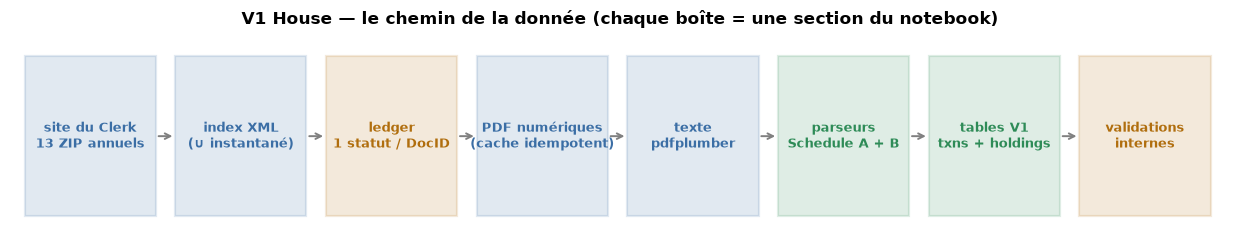

In [3]:
# ── §0.3 Le chemin de la donnée, en un schéma ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12.5, 2.6)); ax.axis("off")
etapes = [("site du Clerk\n13 ZIP annuels", "#3B6EA5"), ("index XML\n(∪ instantané)", "#3B6EA5"),
          ("ledger\n1 statut / DocID", "#B06E0E"), ("PDF numériques\n(cache idempotent)", "#3B6EA5"),
          ("texte\npdfplumber", "#3B6EA5"), ("parseurs\nSchedule A + B", "#2E8B57"),
          ("tables V1\ntxns + holdings", "#2E8B57"), ("validations\ninternes", "#B06E0E")]
for i, (t, c) in enumerate(etapes):
    ax.add_patch(plt.Rectangle((i * 1.55, 0), 1.35, 1, fc=c, alpha=.15, ec=c, lw=1.6))
    ax.text(i * 1.55 + 0.675, 0.5, t, ha="center", va="center", fontsize=9.5, color=c, fontweight="bold")
    if i:
        ax.annotate("", xy=(i * 1.55, 0.5), xytext=(i * 1.55 - 0.2, 0.5),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.4))
ax.set_xlim(-0.15, len(etapes) * 1.55); ax.set_ylim(-0.15, 1.15)
ax.set_title("V1 House — le chemin de la donnée (chaque boîte = une section du notebook)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## §1 — Les index annuels : la liste officielle… qui s'efface

Le Clerk publie chaque année une archive `{Y}FD.zip` contenant `{Y}FD.xml` : **un bloc
`<Member>` par dépôt**, avec 9 champs (`Prefix, Last, First, Suffix, FilingType, StateDst,
Year, FilingDate, DocID`). On télécharge les 13 archives (le ZIP est gardé comme preuve
brute) et on conserve **les 9 champs** — l'ancien pipeline en jetait trois (`Prefix`,
`Suffix`, `Year`) ; or `Suffix` (Jr/Sr/III) sert à départager les homonymes.

Trois règles, dont une découverte le jour de l'écriture de ce notebook :

1. **L'index annuel est l'autorité d'appartenance** d'un dépôt à l'année. On ne filtre
   **jamais** par fenêtre de dates civile : un ancien filtre de ce genre avait perdu
   **205 PTR** déposés après le 31/12 (retards légitimes, jusqu'à +3 ans).
2. Le champ `Year` (année de couverture déclarée) est conservé mais l'appartenance vient
   du **fichier** : `annee_index`.
3. **La source primaire est périssable.** Le 2026-07-13, l'index 2014 re-téléchargé ne
   contient plus que **11 dépôts** au lieu de 2 788 : le Clerk purge les index au-delà
   de la fenêtre de rétention (~6 ans, STOCK Act). Les **PDF restent servis** — mais la
   *liste de ce qu'il faut demander* ne vit plus que dans notre **instantané** de début
   juillet 2026. Le recensement V1 est donc l'**union** {site aujourd'hui} ∪ {instantané},
   chaque ligne tracée par sa source.

In [4]:
# ── §1.1 Téléchargement idempotent des 13 index + ingestion de l'instantané ──
def telecharger(url, timeout=60, essais=3):
    """GET avec retries simples ; renvoie (bytes, status_code)."""
    for k in range(essais):
        try:
            r = HTTP.get(url, timeout=timeout)
            if r.status_code == 200:
                return r.content, 200
            if r.status_code == 404:
                return b"", 404
        except requests.RequestException:
            pass
        time.sleep(1.5 * (k + 1))
    return b"", -1

sha_index = {}
for y in ANNEES:
    zp = CACHE / "index" / f"{y}FD.zip"
    xp = CACHE / "index" / f"{y}FD.xml"
    if not zp.exists():
        data, st = telecharger(URL_INDEX_ZIP.format(year=y))
        assert st == 200 and data[:2] == b"PK", f"échec ZIP {y} (HTTP {st})"
        zp.write_bytes(data)
        time.sleep(PAUSE_S)
    if not xp.exists():
        with zipfile.ZipFile(zp) as z:
            nom_xml = [n for n in z.namelist() if n.lower().endswith(".xml")]
            assert len(nom_xml) == 1, f"{y} : {len(nom_xml)} XML dans le ZIP"
            xp.write_bytes(z.read(nom_xml[0]))
    sha_index[f"site_{y}"] = hashlib.sha256(xp.read_bytes()).hexdigest()

# l'instantané (copie locale figée début juillet 2026) — copié DANS le cache pour autonomie
for y in ANNEES:
    src = ANCIEN / "data" / "house" / "index" / f"{y}FD.xml"
    dst = CACHE / "index_instantane" / f"{y}FD.xml"
    if not dst.exists():
        shutil.copy2(src, dst)
    sha_index[f"instantane_{y}"] = hashlib.sha256(dst.read_bytes()).hexdigest()

print(f"{len(ANNEES)} index « site » + {len(ANNEES)} index « instantané » en cache")

13 index « site » + 13 index « instantané » en cache


In [5]:
# ── §1.2 Parsing des deux jeux d'index → recensement = UNION tracée ──────────
CHAMPS = ["Prefix", "Last", "First", "Suffix", "FilingType", "StateDst", "Year", "FilingDate", "DocID"]

def parse_index(path, annee):
    root = ET.fromstring(path.read_bytes())
    rows = []
    for m in root.findall("Member"):
        d = {ch.lower(): (m.findtext(ch) or "").strip() for ch in CHAMPS}
        d["annee_index"] = annee
        rows.append(d)
    return rows

site, instantane = [], []
for y in ANNEES:
    site += parse_index(CACHE / "index" / f"{y}FD.xml", y)
    instantane += parse_index(CACHE / "index_instantane" / f"{y}FD.xml", y)
S = pd.DataFrame(site).rename(columns={"docid": "doc_id", "filingtype": "filing_type",
                                       "statedst": "state_district"})
I = pd.DataFrame(instantane).rename(columns={"docid": "doc_id", "filingtype": "filing_type",
                                             "statedst": "state_district"})

# L'instantané est notre référence STABLE : ses comptes sont prouvés et figés.
assert len(I) == 35315, f"instantané : attendu 35 315, lu {len(I)}"
attendu = {"C": 10105, "P": 8252, "X": 5844, "O": 4625, "A": 2298, "D": 2196,
           "W": 1099, "H": 395, "T": 392, "G": 51, "E": 35, "B": 23}
assert dict(I["filing_type"].value_counts()) == attendu, "comptes par type inattendus (instantané)"

# UNION par (doc_id, annee_index) : le site d'aujourd'hui, complété par ce qu'il a purgé.
cle = ["doc_id", "annee_index"]
idx_S, idx_I = S.set_index(cle).index, I.set_index(cle).index
purges   = I[~idx_I.isin(idx_S)]          # dans l'instantané, plus sur le site
nouveaux = S[~idx_S.isin(idx_I)]          # sur le site, pas dans l'instantané (dépôts récents)
recensement = pd.concat([S.assign(source="site"),
                         purges.assign(source="instantane_seul")], ignore_index=True)

print(f"site aujourd'hui : {len(S):,} · instantané : {len(I):,} · union : {len(recensement):,}")
print(f"purgés du site   : {len(purges):,}  (années : {sorted(purges['annee_index'].unique())})")
print(f"nouveaux du site : {len(nouveaux):,}  (années : {sorted(nouveaux['annee_index'].unique())})")
# Les « nouveaux » légitimes sont de deux natures (vérifié ligne à ligne) :
#  (a) dépôts récents, postérieurs à l'instantané (annee_index ≥ 2024, FilingDate juillet 2026+) ;
#  (b) vieux dossiers PAPIER re-publiés dans un index purgé (préfixe 7/8/9 — ex. 7 staffers 2014).
assert set(purges["annee_index"]) <= {2014}, "purge inattendue hors 2014 — investiguer !"
recents     = nouveaux["annee_index"] >= 2024
vieux_scans = nouveaux["doc_id"].str[0].isin({"7", "8", "9"})
assert (recents | vieux_scans).all(), "ajout ni récent ni papier-republié — investiguer !"
n_p_nouveaux = int((nouveaux["filing_type"] == "P").sum())
print(f"dont {n_p_nouveaux} nouveaux PTR (P) absents de l'ancien pipeline — la V1 est plus fraîche")

recensement["filing_date"] = pd.to_datetime(recensement["filingdate"], errors="coerce")
recensement["prefixe_docid"] = recensement["doc_id"].str[:1]

# Réalité des index (mesurée, pas idéalisée) :
#  - FilingDate peut être VIDE, mais uniquement sur des types administratifs (W/D/X/E) ;
#  - le DocID fait 7-8 chiffres, SAUF les W numériques : 4 chiffres commençant par 6.
# Les types à contenu (P/C/O/H/T/A) sont, eux, toujours complets — on l'exige.
en_perimetre = recensement["filing_type"].isin(TYPES_PARSES)
sans_date = recensement["filing_date"].isna()
assert not (en_perimetre & sans_date).any(), "FilingDate manquante sur un type en périmètre !"
print(f"FilingDate vide : {int(sans_date.sum())} lignes, toutes hors périmètre — "
      f"{dict(recensement.loc[sans_date, 'filing_type'].value_counts())}")
assert recensement.loc[en_perimetre, "doc_id"].str.fullmatch(r"\d{7,8}").all(), \
    "DocID hors format sur un type en périmètre !"
assert recensement["doc_id"].str.fullmatch(r"\d{4,8}").all(), "DocID totalement hors format"

recensement.drop(columns=["filingdate"]).to_csv(TABLES / "01_recensement_depots.csv", index=False)
print(f"\nrecensement UNION : {len(recensement):,} dépôts · "
      f"{recensement['doc_id'].nunique():,} DocID uniques")
print(f"écrit → {TABLES/'01_recensement_depots.csv'}")

site aujourd'hui : 32,593 · instantané : 35,315 · union : 35,377
purgés du site   : 2,784  (années : [np.int64(2014)])
nouveaux du site : 62  (années : [np.int64(2014), np.int64(2024), np.int64(2025), np.int64(2026)])
dont 15 nouveaux PTR (P) absents de l'ancien pipeline — la V1 est plus fraîche
FilingDate vide : 694 lignes, toutes hors périmètre — {'W': np.int64(651), 'D': np.int64(37), 'X': np.int64(5), 'E': np.int64(1)}

recensement UNION : 35,377 dépôts · 35,359 DocID uniques
écrit → cache/tables/01_recensement_depots.csv


> **⚠️ Découverte V1 — la source primaire s'efface.** Entre début juillet 2026 (instantané)
> et aujourd'hui, le Clerk a **purgé 2 777 des 2 788 dépôts de l'index 2014** (fenêtre de
> rétention du STOCK Act). Les PDF 2014, eux, répondent encore — vérifié — mais sans la
> liste des DocID, on ne saurait plus *quoi* demander. Conséquences :
> 1. l'**instantané des index est un actif critique** (versionné dans l'ancien dépôt,
>    copié dans ce cache) ;
> 2. le mode « preuve complète » (`FULL_REDOWNLOAD`) reste possible pour les **PDF**, mais
>    plus pour les **index** ≤ 2014 — et 2015 tombera à son tour ;
> 3. chaque ligne du recensement porte sa `source` (`site` / `instantane_seul`) ;
> 4. l'index bouge **dans les deux sens** : le site d'aujourd'hui apporte aussi ~55 dépôts
>    déposés après l'instantané (dont ~15 nouveaux PTR) et 7 vieux dossiers papier 2014
>    re-publiés — l'union capture tout.

In [6]:
# ── §1.3 Les doublons de DocID inter-index : qui sont-ils ? ───────────────────
# L'union compte les dépôts listés dans DEUX index d'années différentes (même DocID).
# L'ancien code affirmait « zéro chevauchement » — vérifions factuellement.
dup_ids = recensement.loc[recensement["doc_id"].duplicated(keep=False)].sort_values(
    ["doc_id", "annee_index"])
print(f"{len(dup_ids)} lignes concernées ({dup_ids['doc_id'].nunique()} DocID en double) :")
display(dup_ids[["doc_id", "last", "first", "filing_type", "annee_index", "year",
                 "filing_date", "source"]])

# Verdict factuel : même dépôt (mêmes champs) listé dans deux index consécutifs.
# Règle V1 : le RECENSEMENT reste fidèle aux fichiers (toutes les lignes) ; le LEDGER (§3)
# aura UNE ligne par DocID — on garde la 1re apparition (annee_index la plus ancienne).
recensement["doublon_index"] = recensement.sort_values("annee_index")["doc_id"].duplicated(keep="first")
recensement.sort_index(inplace=True)
meme_type = (dup_ids.groupby("doc_id")["filing_type"].nunique() == 1).all()
valider("L2a", "DocID listés dans deux index (lignes doublonnées)",
        int(recensement["doublon_index"].sum()),
        unite="document", perimetre="tous types, House", vert=25, sens="<=", section="§1.3")
print(f"tous les doublons portent le même FilingType des deux côtés : {meme_type}")

35 lignes concernées (17 DocID en double) :


,doc_id,last,first,filing_type,annee_index,year,filing_date,source
35008,10004456,Spees,Kristen,A,2014,2014,2014-10-01,instantane_seul
35009,10004456,Spees,Kristen,A,2014,2014,2014-10-01,instantane_seul
1478,10008220,Mowery,Tod,C,2015,2015,2015-07-14,site
1479,10008220,Mowery,Tod,C,2015,2015,2015-07-14,site
35046,10008372,Stutzman,Marlin A.,O,2014,2014,2015-08-09,instantane_seul
35047,10008372,Stutzman,Marlin A.,O,2014,2014,2015-08-09,instantane_seul
2617,10012045,Cain,Emily,C,2016,2016,2016-05-15,site
2618,10012045,Cain,Emily,C,2016,2016,2016-05-15,site
7243,10014455,Neugebauer,Randy,T,2017,2017,2017-02-17,site
7244,10014455,Neugebauer,Randy,T,2017,2017,2017-02-17,site


🟢 [L2a] DocID listés dans deux index (lignes doublonnées) = 18  (document · tous types, House · 2014-2026)
tous les doublons portent le même FilingType des deux côtés : True


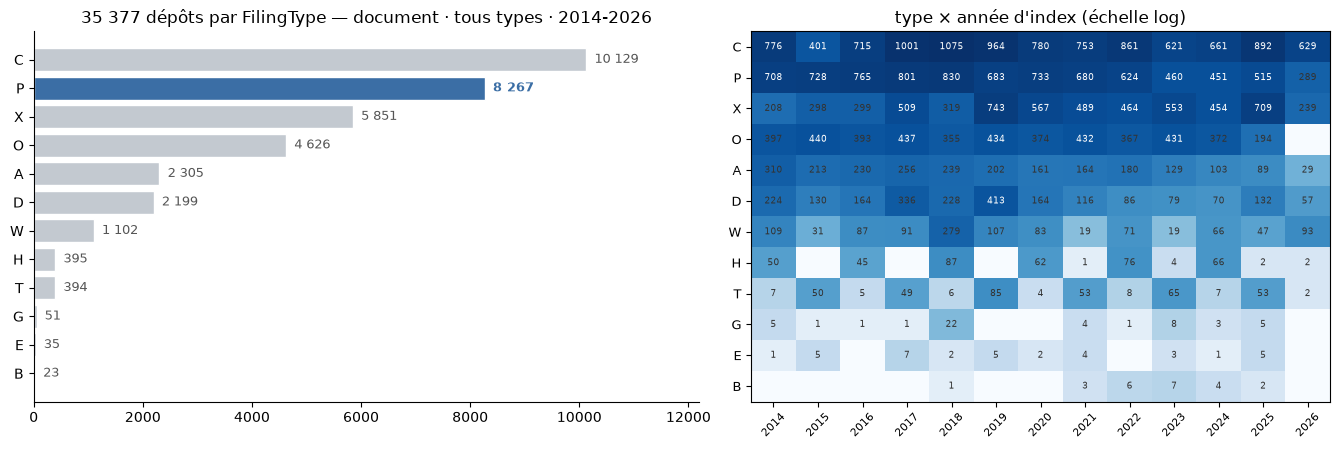

In [7]:
# ── §1.4 Figures : les 12 types, et leur répartition dans le temps ────────────
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), gridspec_kw={"width_ratios": [1.15, 1]})
o = recensement["filing_type"].value_counts()
couleurs = ["#3B6EA5" if t == "P" else "#c3c9d0" for t in o.index]
axes[0].barh(o.index[::-1], o.values[::-1], color=couleurs[::-1], edgecolor="white")
for i, (t, v) in enumerate(zip(o.index[::-1], o.values[::-1])):
    axes[0].text(v + 150, i, f"{v:,}".replace(",", " "), va="center", fontsize=9,
                 fontweight="bold" if t == "P" else "normal",
                 color="#3B6EA5" if t == "P" else "#555")
axes[0].set_title(f"{len(recensement):,} dépôts par FilingType — document · tous types · 2014-2026"
                  .replace(",", " "))
axes[0].set_xlim(0, 12200); axes[0].spines[["top", "right"]].set_visible(False)

piv = recensement.pivot_table(index="filing_type", columns="annee_index",
                              values="doc_id", aggfunc="count").fillna(0)
piv = piv.reindex(o.index)
im = axes[1].imshow(np.log1p(piv.values), cmap="Blues", aspect="auto")
axes[1].set_xticks(range(len(piv.columns)), piv.columns, rotation=45, fontsize=8)
axes[1].set_yticks(range(len(piv.index)), piv.index, fontsize=9)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = int(piv.values[i, j])
        if v:
            axes[1].text(j, i, v, ha="center", va="center", fontsize=6.4,
                         color="white" if v > 400 else "#333")
axes[1].set_title("type × année d'index (échelle log)")
plt.tight_layout(); plt.show()

### Les 12 FilingTypes — significations **vérifiées en ouvrant les documents**

(effectifs de l'instantané, 35 315 dépôts ; l'union ajoute ~55 dépôts récents 2024-2026)

| Code | Nom (imprimé dans le document) | Dépôts | Transactions ? | Exemple réel (cliquable) |
|---|---|---:|---|---|
| **P** | **Periodic Transaction Report** | **8 252** | **oui — notre signal** | [Allen 2023](https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2023/20022986.pdf) |
| C | Candidate Report | 10 105 | Schedule B possible | [Hollier 2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/10056211.pdf) |
| X | Extension Request (délai) | 5 844 | non | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/30019473.pdf) |
| O | Annual Report (bilan annuel) | 4 625 | **oui — Schedule B** | [Adams 2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/10059952.pdf) |
| A | Amendment (corrige O/C/H/T) | 2 298 | oui | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/10062190.pdf) |
| D | Campaign Notice (numérique) | 2 196 | non | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/40003491.pdf) |
| W | Campaign Notice / retrait (papier) | 1 099 | non | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/8219940.pdf) |
| H | New Filer Report (entrée en fonction) | 395 | oui — Schedule B | [Amo 2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/10062638.pdf) |
| T | Terminated Filer Report (sortie) | 392 | oui — Schedule B | [Axne 2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/10050798.pdf) |
| G | Gift Waiver Request | 51 | non | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/8219737.pdf) |
| E | Terminated Employee Exemption | 35 | non | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/8219324.pdf) |
| B | Blind Trust (courrier gestionnaire) | 23 | oui, non dirigées par l'élu | [2023](https://disclosures-clerk.house.gov/public_disc/financial-pdfs/2023/8219364.pdf) |

**Pourquoi C/H/O/T/A nous intéressent au-delà de P** : leur **Schedule A** photographie le
*patrimoine détenu* (entrée en fonction pour H, chaque année pour O, sortie pour T) — c'est
la matière première des validations de cohérence de portefeuille (§11). Leur Schedule B
recoupe les PTR de la même année.

## §2 — Anatomie d'un DocID : numérique ou scanné, et où vit le PDF

Le **premier caractère du DocID** encode le mode de dépôt :

- **numérique** (formulaire en ligne → PDF texte) : `1` (C/O/H/T/A), `2` (P), `3` (X), `4` (D)
- **scanné** (papier numérisé → image) : `7`, `8`, `9` — tous types
- cas résiduels : `5` (G) ; les W numériques ont un DocID **court de 4 chiffres** en `6xxx`

Deux règles d'URL, apprises en ouvrant les documents :
- type `P` → `…/public_disc/ptr-pdfs/{année}/{DocID}.pdf`
- **tous les autres types** → `…/public_disc/financial-pdfs/{année}/{DocID}.pdf`

L'ancien pipeline classait lisible/non-lisible **uniquement** en testant si pdfplumber
extrait du texte. La V1 calcule **les deux signaux** (préfixe ET contenu) et affichera leur
matrice de confusion (§5) : tout désaccord est une anomalie à expliquer, pas un routage
silencieux.

prefixe_docid,1,2,3,4,5,6,7,8,9
filing_type,,,,,,,,,
P,0,5842,0,0,0,0,0,862,1563
C,8546,0,0,0,0,0,0,669,914
X,0,0,4575,0,0,0,0,530,746
O,3905,0,0,0,0,0,0,227,494
A,1872,0,0,0,0,0,0,119,314
D,0,0,0,915,0,0,0,546,738
W,0,0,0,0,0,163,190,324,425
H,383,0,0,0,0,0,0,3,9
T,292,0,0,0,0,0,0,31,71


🟢 [D1] part des PTR numériques (préfixe 2) = 70.7  (document · P, House · 2014-2026)
P : 5,842 numériques + 2,425 scannés = 8,267  (document · P, House · 2014-2026 : 70.7 % / 29.3 %)


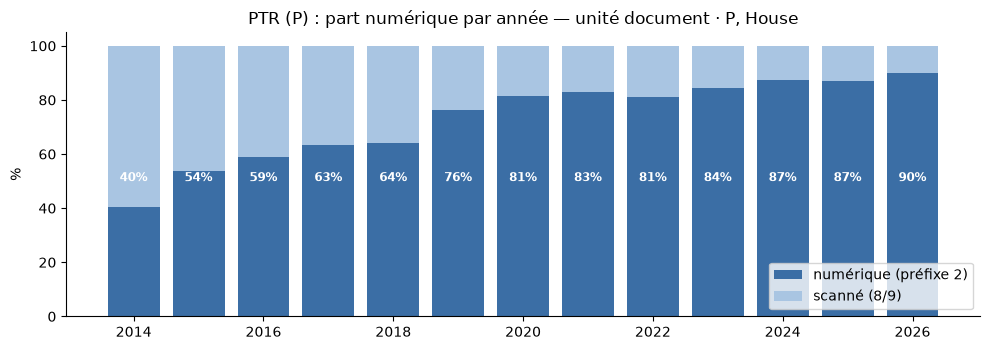

In [8]:
# ── §2.1 Matrice préfixe × type + trajectoire des P ──────────────────────────
PREFIXES_SCANNES = {"7", "8", "9"}
recensement["scanne"] = recensement["prefixe_docid"].isin(PREFIXES_SCANNES)

croise = pd.crosstab(recensement["filing_type"], recensement["prefixe_docid"])
croise = croise.reindex(index=list("PCXOADWHTGEB"))
display(croise)

# les P n'ont que des préfixes 2 (numérique) / 8,9 (scanné) — vérité structurelle
p = recensement[recensement["filing_type"] == "P"]
assert set(p["prefixe_docid"]) <= {"2", "8", "9"}, "préfixe inattendu chez les P"
n_elec, n_scan = int((~p["scanne"]).sum()), int(p["scanne"].sum())
valider("D1", "part des PTR numériques (préfixe 2)", pct(n_elec, len(p)),
        unite="document", perimetre="P, House", vert=60, sens=">=", section="§2.1")
print(f"P : {n_elec:,} numériques + {n_scan:,} scannés = {len(p):,}  "
      f"(document · P, House · 2014-2026 : {pct(n_elec, len(p))} % / {pct(n_scan, len(p))} %)")

fig, ax = plt.subplots(figsize=(10, 3.6))
par_an = p.groupby("annee_index")["scanne"].agg(total="size", scannes="sum")
par_an["elec"] = par_an["total"] - par_an["scannes"]
ax.bar(par_an.index, 100 * par_an["elec"] / par_an["total"], color="#3B6EA5", label="numérique (préfixe 2)")
ax.bar(par_an.index, 100 * par_an["scannes"] / par_an["total"],
       bottom=100 * par_an["elec"] / par_an["total"], color="#A9C5E2", label="scanné (8/9)")
for x, r in par_an.iterrows():
    ax.text(x, 50, f"{100*r['elec']/r['total']:.0f}%", ha="center", fontsize=8.5,
            color="white", fontweight="bold")
ax.set_title("PTR (P) : part numérique par année — unité document · P, House")
ax.set_ylabel("%"); ax.legend(loc="lower right"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## §3 — Le ledger : un statut pour chacun des dépôts

Le défaut le plus grave de l'ancien pipeline n'était pas un bug de parsing, mais
l'**absence de comptabilité** : un document pouvait disparaître entre l'index et la table
finale sans laisser de trace (0 transaction extraite ? échec ? écarté ? on ne savait pas).
Sa métrique de « couverture » valait 100 % **par construction**.

Le ledger inverse la logique : **une ligne par DocID, un statut, et la partition doit
retomber exactement sur le total du recensement**. Statuts initiaux (affinés par chaque
étape suivante) :

- `a_traiter` — numérique, type ∈ {P, O, H, T, A, C} : sera téléchargé et parsé ;
- `scanne_hors_V1` — préfixe 7/8/9 : recensé, OCR reporté en V2 ;
- `hors_perimetre_admin` — X (délai), D/W (notices de campagne), G (cadeaux), E (exemption) :
  aucune donnée financière à extraire ;
- `hors_perimetre_blind_trust` — B : transactions non dirigées par l'élu (exclues par principe).

In [9]:
# ── §3.1 Construction du squelette ────────────────────────────────────────────
# 1 ligne par DocID : pour les doublons inter-index, on garde la 1re apparition (§1.3).
ledger = recensement.loc[~recensement["doublon_index"]].copy()

def statut_initial(r):
    if r["filing_type"] == "B":
        return "hors_perimetre_blind_trust"
    if r["filing_type"] in TYPES_HORS_PERIMETRE:
        return "hors_perimetre_admin"
    if r["scanne"]:
        return "scanne_hors_V1"
    return "a_traiter"

ledger["statut"] = ledger.apply(statut_initial, axis=1)
ledger["url_pdf"] = np.where(
    ledger["filing_type"] == "P",
    [URL_PDF_PTR.format(year=y, doc_id=d) for y, d in zip(ledger["annee_index"], ledger["doc_id"])],
    [URL_PDF_FD.format(year=y, doc_id=d) for y, d in zip(ledger["annee_index"], ledger["doc_id"])])

# Partition totale (BLOQUANT) : chaque DocID a exactement un statut,
# et ledger + doublons écartés == recensement (rien ne se perd, rien ne se crée).
assert ledger["doc_id"].is_unique and ledger["statut"].notna().all()
n_partition = len(ledger) + int(recensement["doublon_index"].sum())
valider("L1", "partition du ledger == recensement", int(n_partition == len(recensement)),
        unite="document", perimetre="tous types, House", vert=1,
        bloquant=True, section="§3.1")

bilan = (ledger.groupby(["statut", "filing_type"]).size().unstack(fill_value=0)
         .assign(total=lambda d: d.sum(axis=1)).sort_values("total", ascending=False))
display(bilan)

n_at = int((ledger["statut"] == "a_traiter").sum())
print(f"\nà traiter (numériques P/O/H/T/A/C) : {n_at:,} documents "
      f"(document · P+O/H/T/A+C num, House · 2014-2026)")
ledger.to_csv(TABLES / "02_ledger_docs.csv", index=False)
print(f"écrit → {TABLES/'02_ledger_docs.csv'}  (squelette ; enrichi aux §4-§10)")

🟢 [L1] partition du ledger == recensement = 1  (document · tous types, House · 2014-2026)


filing_type,A,B,C,D,E,G,H,O,P,T,W,X,total
statut,,,,,,,,,,,,,
a_traiter,1870,0,8533,0,0,0,383,3903,5842,291,0,0,20822
hors_perimetre_admin,0,0,0,2199,35,51,0,0,0,0,1102,5851,9238
scanne_hors_V1,433,0,1583,0,0,0,12,721,2425,102,0,0,5276
hors_perimetre_blind_trust,0,23,0,0,0,0,0,0,0,0,0,0,23



à traiter (numériques P/O/H/T/A/C) : 20,822 documents (document · P+O/H/T/A+C num, House · 2014-2026)


écrit → cache/tables/02_ledger_docs.csv  (squelette ; enrichi aux §4-§10)


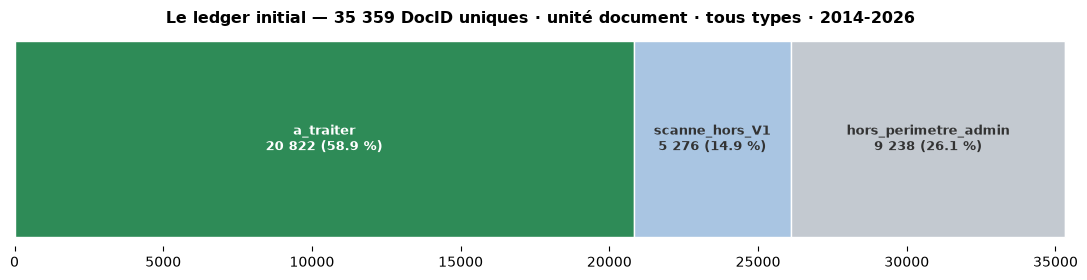

In [10]:
# ── §3.2 Figure : la partition en un coup d'œil ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 2.9))
ordre = ["a_traiter", "scanne_hors_V1", "hors_perimetre_admin", "hors_perimetre_blind_trust"]
coul  = {"a_traiter": "#2E8B57", "scanne_hors_V1": "#A9C5E2",
         "hors_perimetre_admin": "#c3c9d0", "hors_perimetre_blind_trust": "#8a929b"}
tot, x = len(ledger), 0
for s in ordre:
    n = int((ledger["statut"] == s).sum())
    ax.barh([0], [n], left=x, color=coul[s], edgecolor="white", height=0.6)
    if n > 900:
        ax.text(x + n / 2, 0, f"{s}\n{n:,} ({100*n/tot:.1f} %)".replace(",", " "),
                ha="center", va="center", fontsize=9,
                color="white" if s == "a_traiter" else "#333", fontweight="bold")
    x += n
ax.set_xlim(0, tot); ax.set_yticks([]); ax.spines[:].set_visible(False)
ax.set_title(f"Le ledger initial — {tot:,} DocID uniques · unité document · tous types · 2014-2026"
             .replace(",", " "), fontsize=11.5, fontweight="bold")
plt.tight_layout(); plt.show()